This is a simple notebook to assist with quick visualization of the indices dataset.

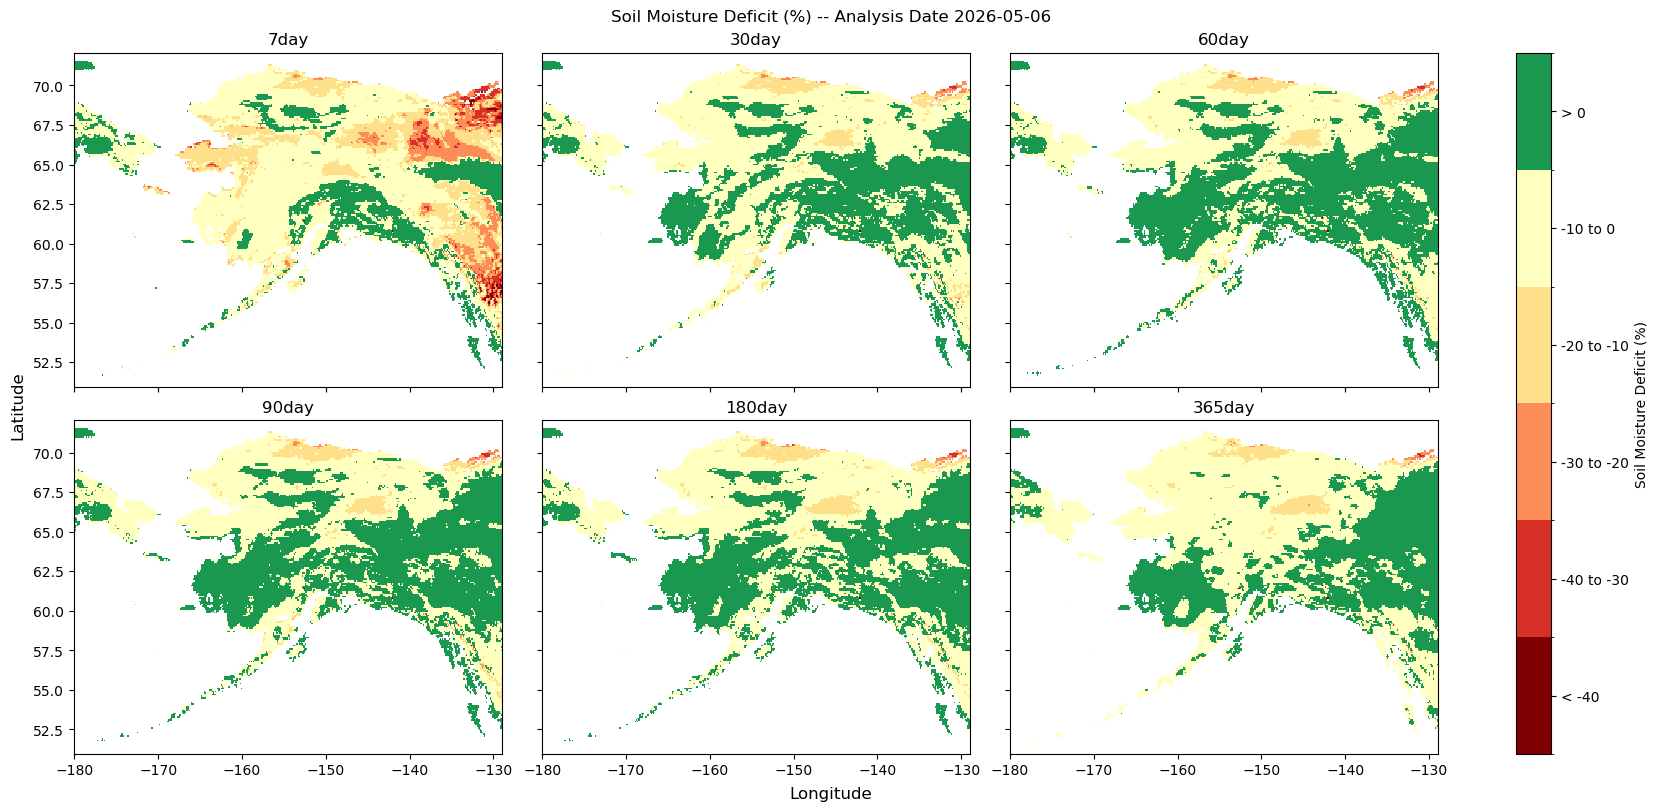

In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm

data_dir = Path("snap/drought_outputs")

all_files = [
    Path("snap/drought_outputs/drought_indices_1day.nc"),
    Path("snap/drought_outputs/drought_indices_7day.nc"),
    Path("snap/drought_outputs/drought_indices_30day.nc"),
    Path("snap/drought_outputs/drought_indices_60day.nc"),
    Path("snap/drought_outputs/drought_indices_90day.nc"),
    Path("snap/drought_outputs/drought_indices_180day.nc"),
    Path("snap/drought_outputs/drought_indices_365day.nc"),
]

variable_key = "smd"
long_name = "Soil Moisture Deficit (%)"

# Define soil moisture deficit categories (%)
# Bins:
#   < -40
#   -40 to -30
#   -30 to -20
#   -20 to -10
#   -10 to 0
#   > 0
bounds = [-100, -40, -30, -20, -10, 0, 100]

colors = [
    "#7f0000",  # < -40%
    "#d73027",  # -40 to -30%
    "#fc8d59",  # -30 to -20%
    "#fee08b",  # -20 to -10%
    "#ffffbf",  # -10 to 0%
    "#1a9850",  # > 0%
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar_labels = [
    "< -40",
    "-40 to -30",
    "-30 to -20",
    "-20 to -10",
    "-10 to 0",
    "> 0",
]

cbar_ticks = [
    -70,
    -35,
    -25,
    -15,
    -5,
    50,
]

short_window_files = [all_files[0]]
long_window_files = all_files[1::]


def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def plot_variable_across_files(
    paths: list[str | Path],
    figsize_per_panel: tuple[float, float] = (5.5, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare the same variable across multiple NetCDF files."""

    ncols = 3
    nrows = 2

    #
    fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
    constrained_layout=True,
    squeeze=False,
    sharex=True,
    sharey=True,
    )

    #
    opened: list[tuple[Path, xr.Dataset]] = []

    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))

    ref_date = ds.attrs["reference_date"]

    mesh = None

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        da = ds[variable_key]
    
        lon = ds["longitude"].values
        lat = ds["latitude"].values
    
        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            norm=norm,
        )
    
        ax.set_title(Path(path).stem.split("_")[-1])
        ax.label_outer()
    
    fig.supxlabel("Longitude")
    fig.supylabel("Latitude")
    if mesh is None:
        raise ValueError("No input files were provided.")

    # Colorbar with categorical labels
    cbar = fig.colorbar(
        mesh,
        ax=axes.ravel().tolist(),
        boundaries=bounds,
        ticks=cbar_ticks,
        spacing="uniform",
    )

    cbar.set_ticklabels(cbar_labels)
    cbar.set_label("Soil Moisture Deficit (%)")

    fig.suptitle(f"{long_name} -- Analysis Date {ref_date}", fontsize=12)

    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")


plot_variable_across_files(long_window_files, save_path="smd.png")